<h2>Quantum Fourier Transform</h2>

In these notes, we will study quantum Fourier transform (QFT) algorithm for computing the Fourier transform of a quantum superposition.

We will derive QFT differently from many online sources emphasizing how the divide-and-conquer of FFT can be converted from a classical divide-and-conquer into a "quantum" divide-and-conquer. H/T to the following note:
Gloria Paradisi, and Hugues Randriam: A presentation of the quantum Fourier transform from a recursive viewpoint , arXiv:quant-ph/0411069, https://arxiv.org/abs/quant-ph/0411069

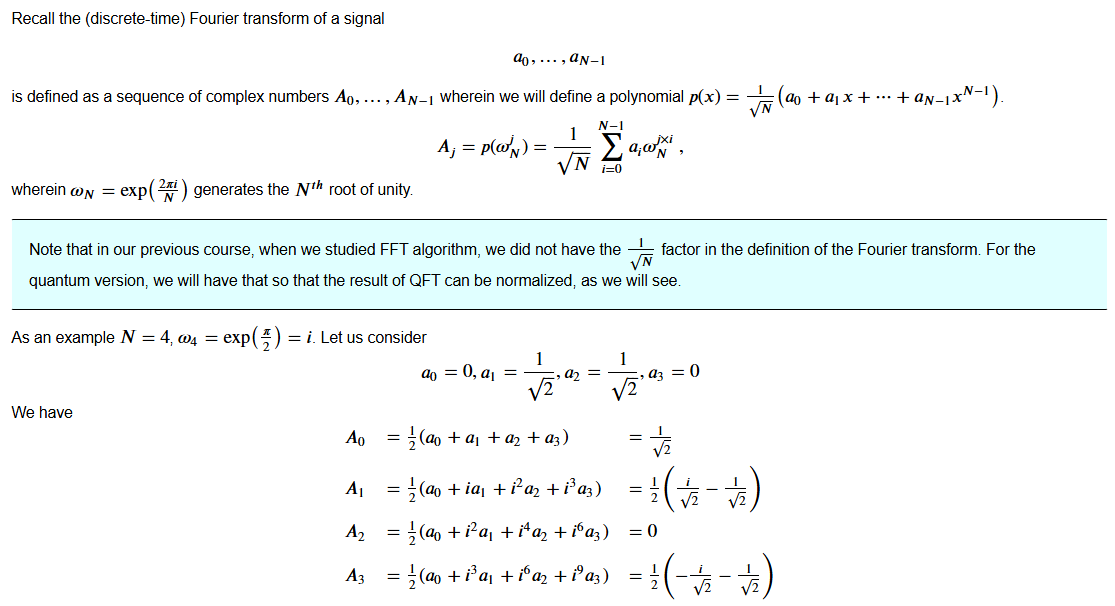
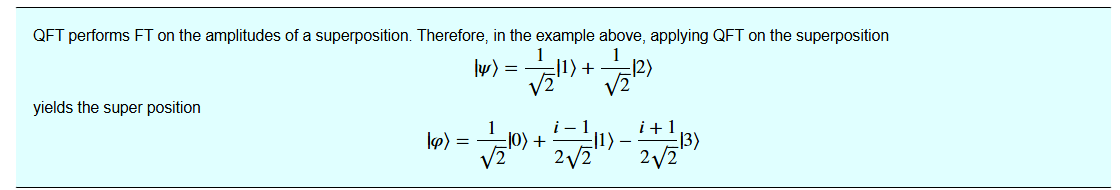

<h2>QFT is a Unitary Operator</h2>
The very first observation is that we can implement Fourier transform on quantum superposition amplitudes because the QFT as defined above is the Unitary operator.

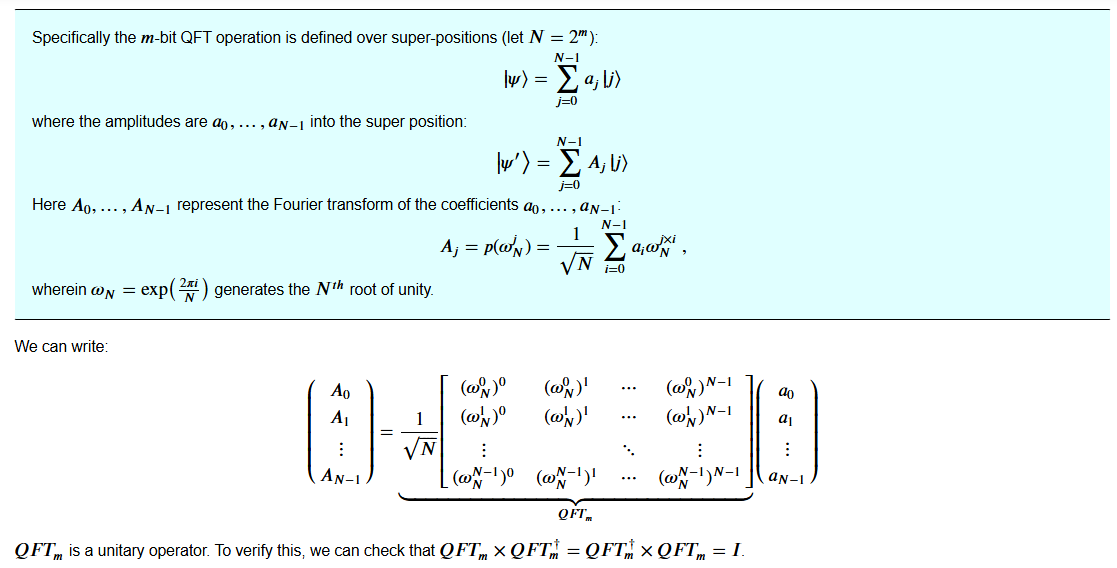

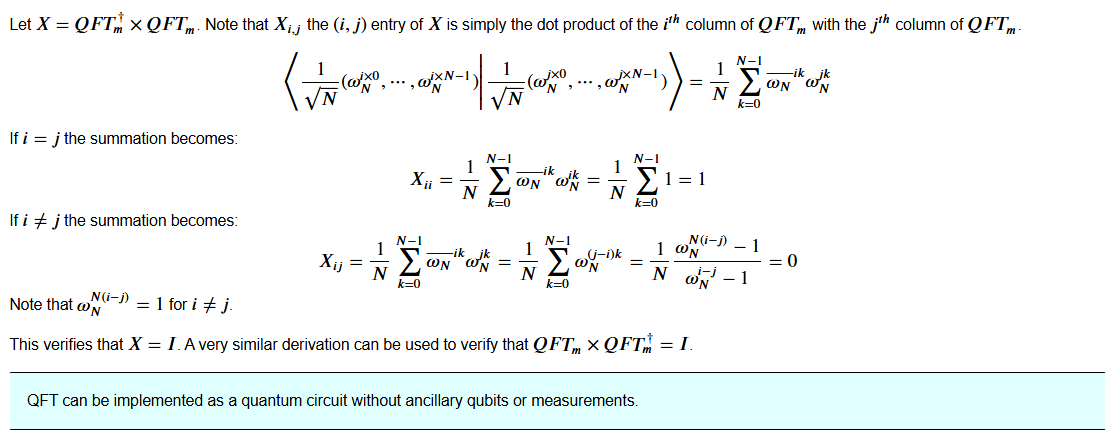

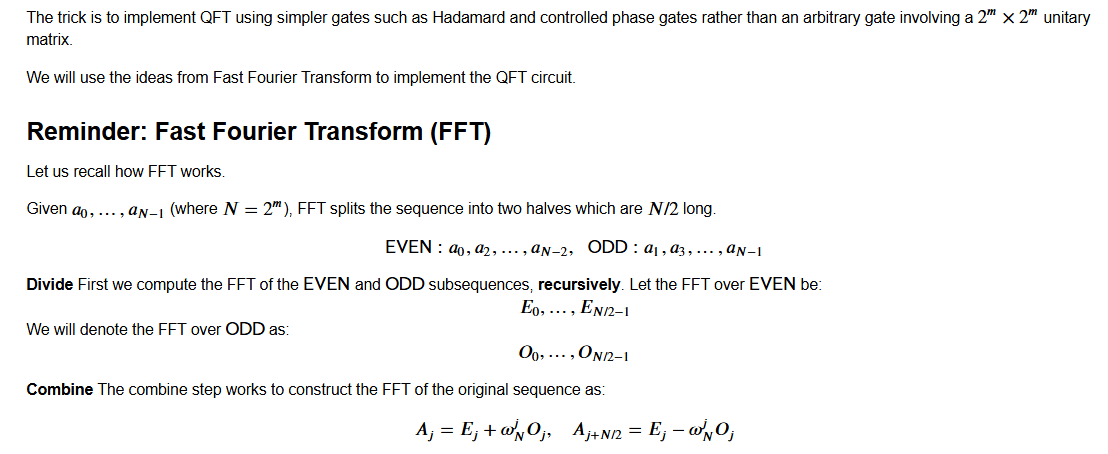


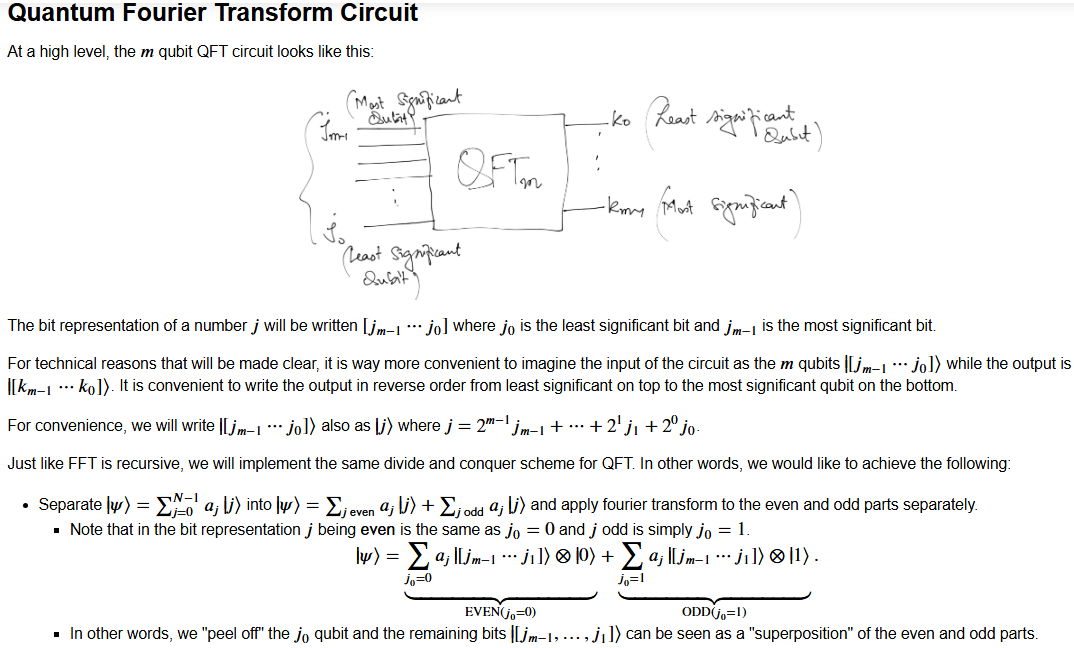

Here comes the main part: recursion is simply achieved by running QFT with  𝑚−1  bits on the initial  𝑚−1   qubits as shown in the figure below:

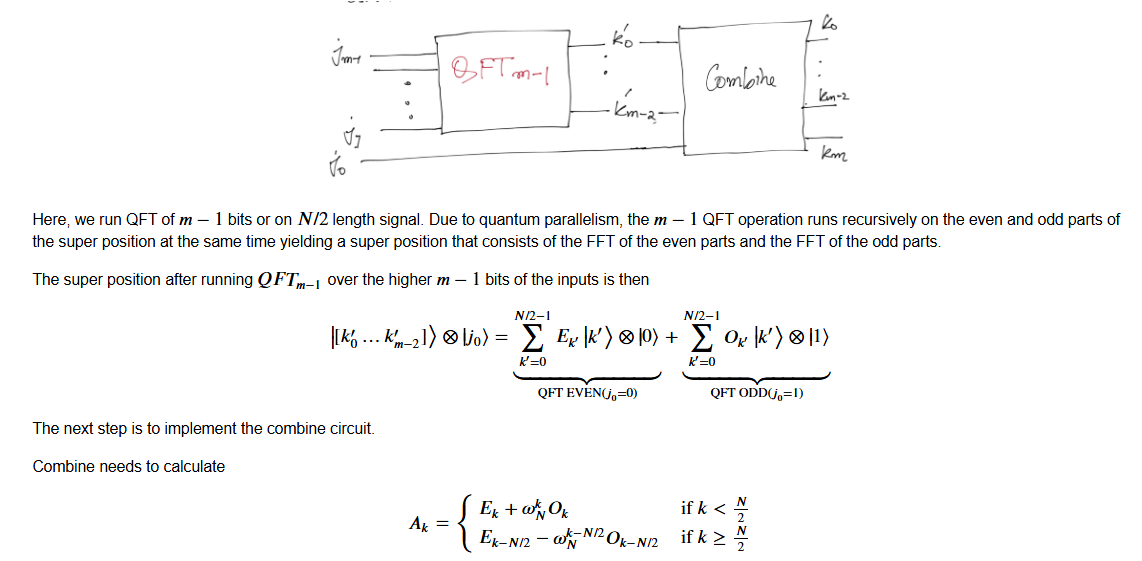
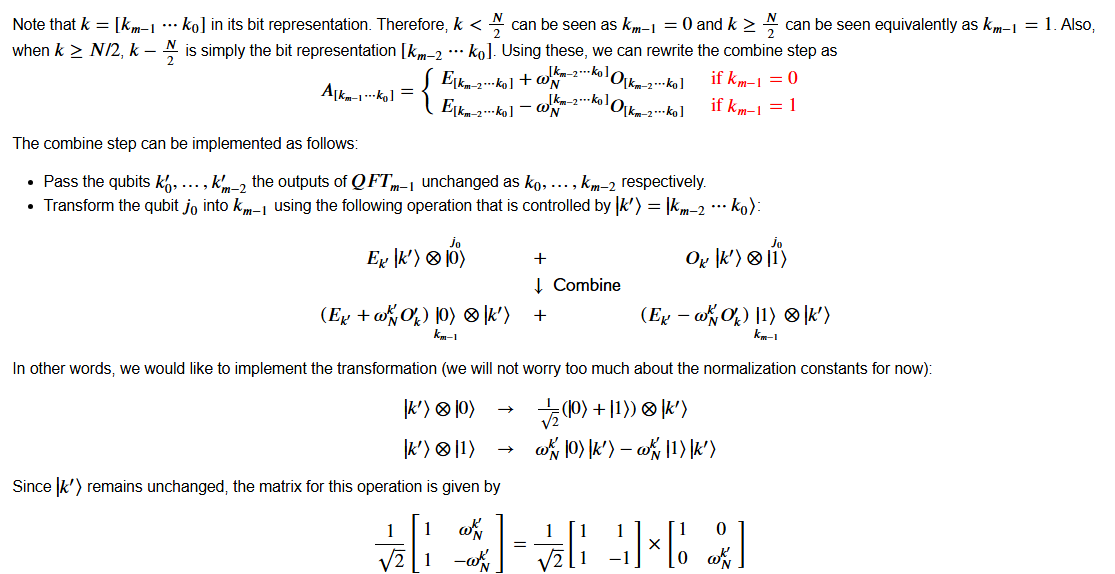
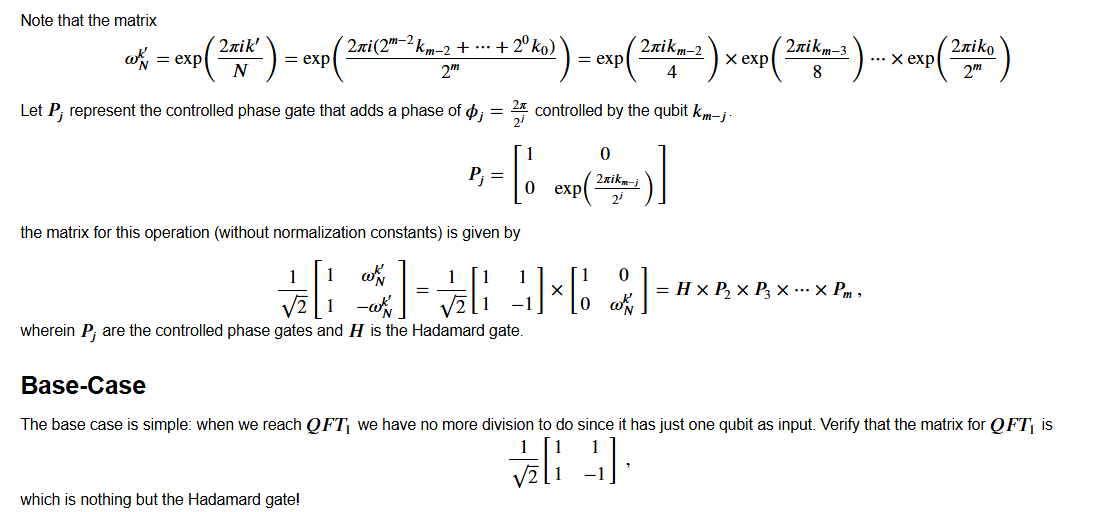
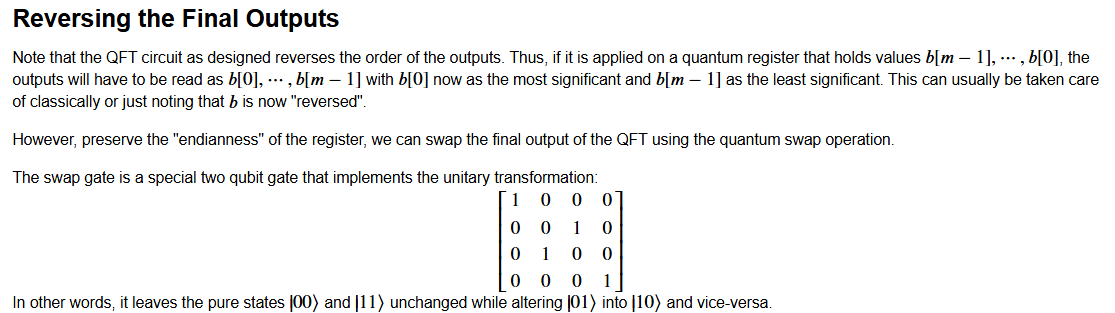

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit_aer import Aer
from numpy import pi
def implement_qft(qc, b): 
    # b is the input quantum register 
    # b[0] is the least significant bit while b[m-1] is the most significant
    m = len(b)
    if m == 1:
        qc.h(b[0]) # base case
        qc.barrier(b, label=f"QFT_{m}")
    else:
        implement_qft(qc, b[1:m]) # implement QFT on the n-1 most significant bits
        # now implement the combine circuit
        # note that the least significant qubit at the output k_0 is b[m-1] now 
        #                      since things flip at the output of the QFT
        # k_1 = b[m-2]
        # ..
        # k_{m-2} = b[1]
        # k_{m-1} = b[0]
       
        for j in range(2,m+1):
            # implement a controlled phase gate 
            # angle = 2*pi/(2^{j}) 
            # control input is k_{m-j}
            i = (m-1) - (m-j)
            qc.cp(2*pi/(2**j), b[i], b[0])
        qc.h(b[0])
        qc.barrier(b, label=f"QFT_{m}")

def reverse_outputs(qc, b):
    # note that the QFT circuit naturally swaps the "endianness of the output"
    # In other words, b[0] is the MSB and b[m-1] is the least significant bit
    # this causes confusion when interpreting the output.
    # We will add swaps to correct this
    m = len(b)
    i = 0
    while i < (m-1)-i:
        qc.swap(b[i], b[m-1-i])
        i = i + 1
    qc.barrier(label="SWAP")

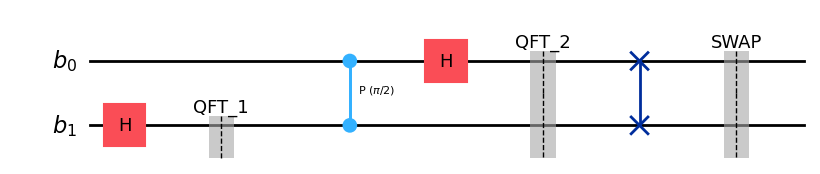

In [3]:
b = QuantumRegister(2, 'b')
qc = QuantumCircuit(b)
implement_qft(qc, b)
reverse_outputs(qc,b)
qc.draw('mpl', style='iqp')

In [8]:
backend = Aer.get_backend('unitary_simulator')
new_circuit = transpile(qc, backend)
job = backend.run(new_circuit, shots=16000)
result = job.result()
print(result.get_unitary(qc,3))

Operator([[ 0.5+0.j ,  0.5-0.j ,  0.5-0.j ,  0.5-0.j ],
          [ 0.5+0.j , -0.5+0.j ,  0.5-0.j , -0.5+0.j ],
          [ 0.5+0.j ,  0. +0.5j, -0.5+0.j , -0. -0.5j],
          [ 0.5+0.j , -0. -0.5j, -0.5+0.j ,  0. +0.5j]],
         input_dims=(2, 2), output_dims=(2, 2))


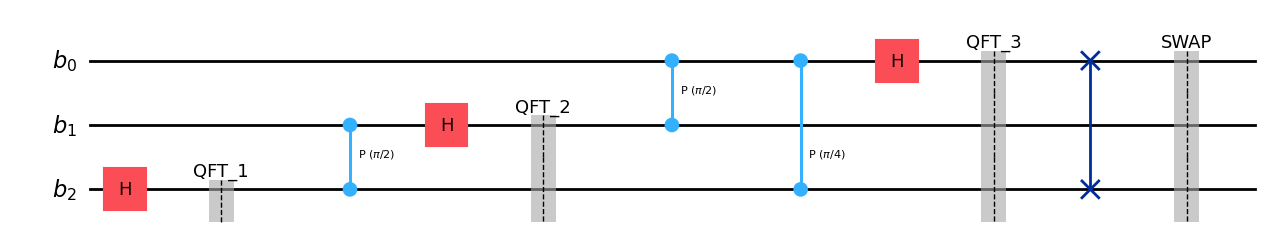

Operator([[ 0.3536+0.j    ,  0.3536-0.j    ,  0.3536-0.j    ,
            0.3536-0.j    ,  0.3536-0.j    ,  0.3536-0.j    ,
            0.3536-0.j    ,  0.3536-0.j    ],
          [ 0.3536+0.j    , -0.3536+0.j    ,  0.3536-0.j    ,
           -0.3536+0.j    ,  0.3536-0.j    , -0.3536+0.j    ,
            0.3536-0.j    , -0.3536+0.j    ],
          [ 0.3536+0.j    ,  0.    +0.3536j, -0.3536+0.j    ,
           -0.    -0.3536j,  0.3536-0.j    ,  0.    +0.3536j,
           -0.3536+0.j    , -0.    -0.3536j],
          [ 0.3536+0.j    , -0.    -0.3536j, -0.3536+0.j    ,
            0.    +0.3536j,  0.3536-0.j    , -0.    -0.3536j,
           -0.3536+0.j    ,  0.    +0.3536j],
          [ 0.3536+0.j    ,  0.25  +0.25j  ,  0.    +0.3536j,
           -0.25  +0.25j  , -0.3536+0.j    , -0.25  -0.25j  ,
           -0.    -0.3536j,  0.25  -0.25j  ],
          [ 0.3536+0.j    , -0.25  -0.25j  ,  0.    +0.3536j,
            0.25  -0.25j  , -0.3536+0.j    ,  0.25  +0.25j  ,
           -0.    -0.3536j

In [10]:
b = QuantumRegister(3, 'b')
qc = QuantumCircuit(b)
implement_qft(qc, b)
reverse_outputs(qc,b)
display(qc.draw('mpl', style='iqp'))
backend = Aer.get_backend('unitary_simulator')
new_circuit = transpile(qc, backend)
job = backend.run(new_circuit, shots=16000)
result = job.result()
print(result.get_unitary(qc,4))

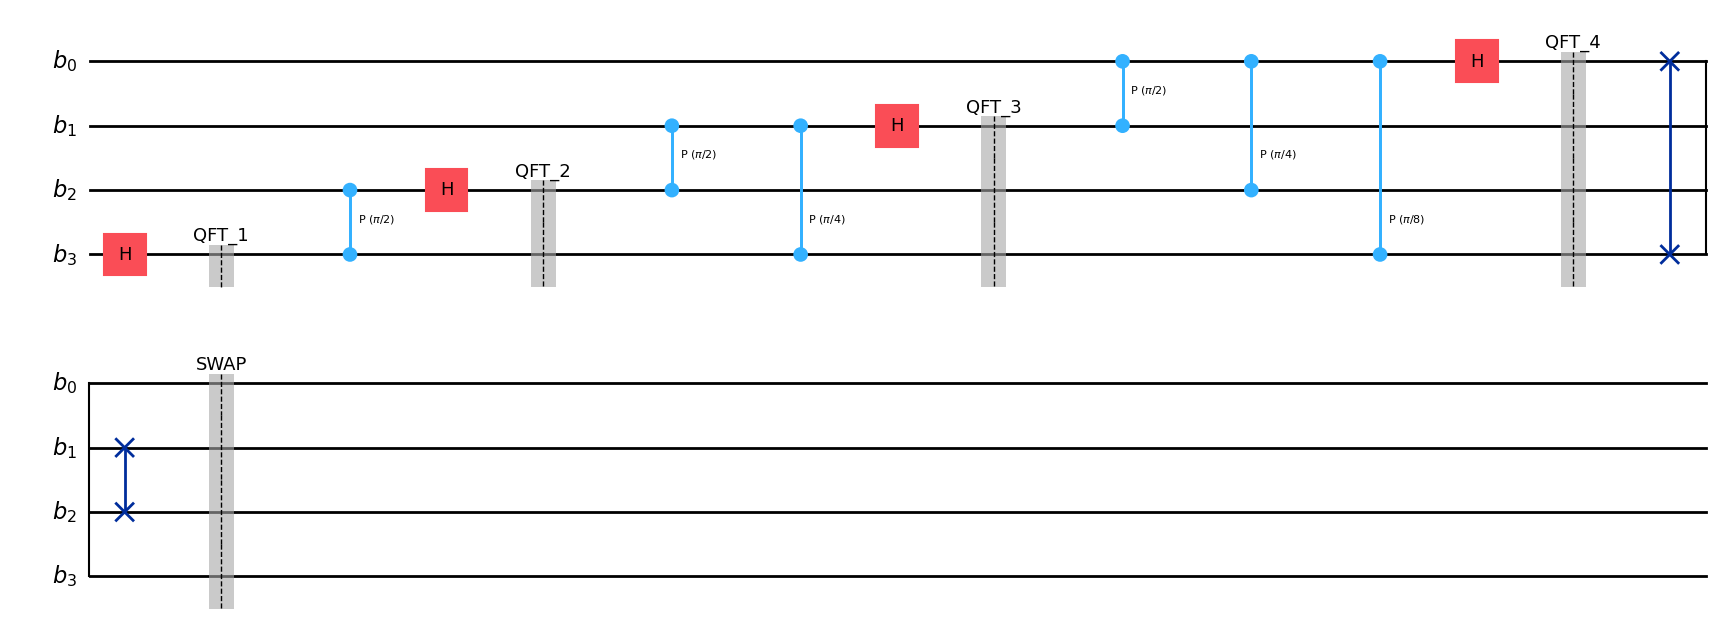

Operator([[ 0.25  +0.j    ,  0.25  -0.j    ,  0.25  -0.j    ,
            0.25  -0.j    ,  0.25  -0.j    ,  0.25  -0.j    ,
            0.25  -0.j    ,  0.25  -0.j    ,  0.25  -0.j    ,
            0.25  -0.j    ,  0.25  -0.j    ,  0.25  -0.j    ,
            0.25  -0.j    ,  0.25  -0.j    ,  0.25  -0.j    ,
            0.25  -0.j    ],
          [ 0.25  +0.j    , -0.25  +0.j    ,  0.25  -0.j    ,
           -0.25  +0.j    ,  0.25  -0.j    , -0.25  +0.j    ,
            0.25  -0.j    , -0.25  +0.j    ,  0.25  -0.j    ,
           -0.25  +0.j    ,  0.25  -0.j    , -0.25  +0.j    ,
            0.25  -0.j    , -0.25  +0.j    ,  0.25  -0.j    ,
           -0.25  +0.j    ],
          [ 0.25  +0.j    ,  0.    +0.25j  , -0.25  +0.j    ,
           -0.    -0.25j  ,  0.25  -0.j    ,  0.    +0.25j  ,
           -0.25  +0.j    , -0.    -0.25j  ,  0.25  -0.j    ,
            0.    +0.25j  , -0.25  +0.j    , -0.    -0.25j  ,
            0.25  -0.j    ,  0.    +0.25j  , -0.25  +0.j    ,
           -

In [11]:
b = QuantumRegister(4, 'b')
qc = QuantumCircuit(b)
implement_qft(qc, b)
reverse_outputs(qc,b)
display(qc.draw('mpl', style='iqp'))
backend = Aer.get_backend('unitary_simulator')
new_circuit = transpile(qc, backend)
job = backend.run(new_circuit, shots=16000)
result = job.result()
print(result.get_unitary(qc,4))